# Exploration of the Global Surface Water data

In [1]:
import os
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from pyproj import Transformer
import pandas as pd
import re
from pathlib import Path

In [2]:
gsw_dir = "../datasets/river_dataset"

## Visualization

In [16]:
# plot rivers within a specific file (now for .tif raster files)
def plot_rivers(data_dir, ax=None, water_threshold=1, max_pixels=1000):
    """
    Plot river occurrence from a GSW raster file, downsampling for memory safety.
    """
    with rasterio.open(data_dir) as src:
        # Calculate downsampling factor
        factor = max(1, int(max(src.width, src.height) / max_pixels))
        data = src.read(
            1,
            out_shape=(
                1,
                src.height // factor,
                src.width // factor
            ),
            resampling=rasterio.enums.Resampling.nearest
        )
        mask = data >= water_threshold

        if ax is None:
            fig, ax = plt.subplots(figsize=(8, 8))
        ax.imshow(mask, cmap="Blues", interpolation="nearest")
        # ax.set_title("River Occurrence Map")
        ax.axis("off")
        plt.show()
        return ax

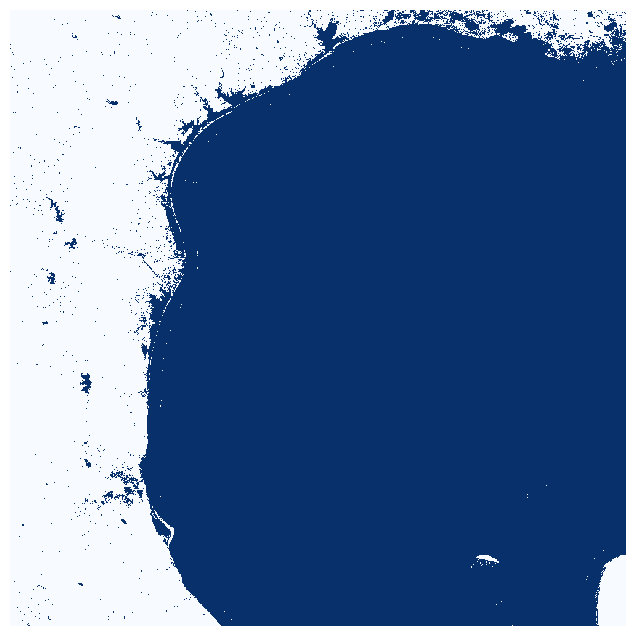

<Axes: >

In [22]:
# plot_rivers(data_dir="../datasets/river_dataset/occurrence_110W_30Nv1_4_2021.tif")
# plot_rivers(data_dir="../datasets/river_dataset/occurrence_90W_30Nv1_4_2021.tif")
plot_rivers(data_dir="../datasets/river_dataset/occurrence_100W_30Nv1_4_2021.tif")

## River distance from coords

In [3]:
def distance_to_river_in_file(lat, lon, tif_path, water_threshold=1, max_search_km=50, step_pixels=256):
    """
    Returns the distance (in meters) from (lat, lon) to the nearest river pixel in the given GSW .tif file.
    Only searches within max_search_km from the point for memory safety.
    """

    if not os.path.exists(tif_path):
        return np.nan

    with rasterio.open(tif_path) as src:
        # Transform point to raster CRS
        transformer = Transformer.from_crs("EPSG:4326", src.crs, always_xy=True)
        x, y = transformer.transform(lon, lat)

        # Convert to pixel indices
        try:
            row, col = src.index(x, y)
        except Exception:
            return np.nan  # point outside raster

        px_size = abs(src.transform.a)
        max_radius_px = int((max_search_km * 1000) / px_size)

        for radius in range(step_pixels, max_radius_px + step_pixels, step_pixels):
            row_min = max(row - radius, 0)
            row_max = min(row + radius + 1, src.height)
            col_min = max(col - radius, 0)
            col_max = min(col + radius + 1, src.width)

            height = row_max - row_min
            width = col_max - col_min

            if height <= 0 or width <= 0:
                continue

            window = rasterio.windows.Window(
                col_off=col_min,
                row_off=row_min,
                width=width,
                height=height
            )

            data = src.read(1, window=window)
            mask = data >= water_threshold
            if not mask.any():
                continue

            rows, cols = np.where(mask)
            xs, ys = rasterio.transform.xy(
                src.transform,
                rows + row_min,
                cols + col_min
            )

            # Calculate geodesic distance if CRS is geographic
            if src.crs.is_geographic:
                from pyproj import Geod
                geod = Geod(ellps="WGS84")
                transformer_rev = Transformer.from_crs(src.crs, "EPSG:4326", always_xy=True)
                lons, lats = transformer_rev.transform(xs, ys)
                _, _, dists = geod.inv([lon]*len(lons), [lat]*len(lats), lons, lats)
                return float(np.min(dists))
            else:
                dx = np.array(xs) - x
                dy = np.array(ys) - y
                return float(np.sqrt(dx * dx + dy * dy).min())

        return np.nan

In [4]:
files = [f for f in os.listdir(gsw_dir) if f.endswith('.tif')]
def find_gsw_file_for_coords(lat, lon, gsw_dir):
    """
    Given latitude and longitude, find the GSW file in gsw_dir that contains the point.
    Assumes files are named like 'occurrence_70W_50Nv1_4_2021.tif'.
    Returns the full path to the file, or None if not found.
    """
    for fname in files:
        # Example: occurrence_70W_50Nv1_4_2021.tif
        m = re.search(r'occurrence_(\d+)([EW])_(\d+)([NS])', fname)
        if not m:
            continue
        lon0, ew, lat0, ns = m.groups()
        lon0 = int(lon0)
        lat0 = int(lat0)
        # Determine file's NW corner
        file_lon = -lon0 if ew == 'W' else lon0
        file_lat = lat0 if ns == 'N' else -lat0
        # Each file is 10x10 degrees (GSW convention)
        lon1 = file_lon + 10
        lat1 = file_lat - 10
        if file_lon <= lon < lon1 and lat1 < lat <= file_lat:
            return os.path.join(gsw_dir, fname)
    raise Exception("No matching GSW file found for the given coordinates")

In [5]:
lat = 35.900286
lon = -119.984057
tif_path = find_gsw_file_for_coords(lat, lon, gsw_dir)
print(tif_path)

dist = distance_to_river_in_file(lat, lon, tif_path)
print(f"{dist:.1f} meters")

../datasets/river_dataset\occurrence_120W_40Nv1_4_2021.tif
6026.5 meters


## Add feats to the dataset

In [66]:
# Define paths to the storm events CSV files
data_dir = Path('../datasets\\')
files = [
    data_dir / 'StormEvents_details-ftp_v1.0_d2016_c20250818.csv',
    data_dir / 'StormEvents_details-ftp_v1.0_d2017_c20250520.csv',
    data_dir / 'StormEvents_details-ftp_v1.0_d2018_c20250520.csv',
    data_dir / 'StormEvents_details-ftp_v1.0_d2019_c20250520.csv',
    data_dir / 'StormEvents_details-ftp_v1.0_d2020_c20251118.csv',
    data_dir / 'StormEvents_details-ftp_v1.0_d2021_c20250520.csv',
    data_dir / 'StormEvents_details-ftp_v1.0_d2022_c20250721.csv',
]

# Load datasets
print("Loading datasets...")
df_list = []
for file in files:
    # print(f"  Loading {file.name}...")
    df = pd.read_csv(file)
    # print(f"    Shape: {df.shape}")
    df_list.append(df)

# Concatenate the datasets
df = pd.concat(df_list, ignore_index=True)
print(f"\nCombined dataset shape: {df.shape}")

Loading datasets...

Combined dataset shape: (436146, 51)


In [67]:
df.drop(columns=[col for col in df.columns if col not in ['INDEX', 'BEGIN_LAT', 'BEGIN_LON']], inplace=True)
df.head()

,BEGIN_LAT,BEGIN_LON
0,34.94,-81.03
1,35.01,-80.93
2,35.64,-82.14
3,35.65,-84.18
4,35.87,-83.77


In [ ]:
# check to have all map patches
for idx, row in df.iterrows():
    lat=row['BEGIN_LAT']
    lon=row['BEGIN_LON']
    if np.isnan(lat) or np.isnan(lon):
        continue
    try: 
        tif_file = find_gsw_file_for_coords(lat, lon, gsw_dir)
    except Exception as e:
        print(e, f" {lat}, {lon}")

In [109]:
df['RIVER_DISTANCE'] = np.nan
for idx, row in df.iterrows():
    lat=row['BEGIN_LAT']
    lon=row['BEGIN_LON']
    if np.isnan(lat) or np.isnan(lon):
        continue
    try: 
        tif_file = find_gsw_file_for_coords(lat, lon, gsw_dir)
        df.loc[idx, 'RIVER_DISTANCE'] = distance_to_river_in_file(lat,lon, tif_file)
    except Exception as e:
        print(e, f" {lat}, {lon}")
    
df.head()

,BEGIN_LAT,BEGIN_LON,RIVER_DISTANCE
0,34.94,-81.03,1248.123533
1,35.01,-80.93,528.226941
2,35.64,-82.14,431.279720
3,35.65,-84.18,842.241460
4,35.87,-83.77,1563.316095


In [110]:
df.drop(columns=['BEGIN_LAT', 'BEGIN_LON'], inplace=True)
df.to_csv(data_dir / 'disasters_new_feats' / 'river_distance.csv', index=False)